# Topic modeling with LDA

## Set corpus type and configure whether to load an existing LDA model or compute it

In [13]:
corpus_type = "title"
corpus_type = "concat"

load_lda_model = True # set to True to load existing model instead of training a new one

## Import dask and set up client for resource dashboard

In [ ]:
from dask import dataframe as dd
from dask.distributed import Client # only for dashboard

client = Client() # only for dashboard
print(client.dashboard_link) # only for dashboard

## Read data set

In [15]:
df = dd.read_parquet("artifacts/Preprocessing/arxiv-metadata-cleaned_LDA.parquet")
# print(df.dtypes)
# print(df.head())

## Read tokenized titles into list of strings

In [16]:
print("Reading tokenized titles...")
titles_tokenized = df["title"].compute().tolist()
if corpus_type == "concat":
    print("Reading tokenized abstracts...")
    abstracts_tokenized = df["abstract"].compute().tolist()

Reading tokenized titles...
Reading tokenized abstracts...


In [17]:
print("Tokenized titles:")
for title in titles_tokenized[:20]:
    print(title)

if corpus_type == "concat":
    print()
    print("Tokenized abstracts:")
    for abstract in abstracts_tokenized[:5]:
        print(abstract)

Tokenized titles:
['dynamical' 'analysis' 'brans-dicke' 'universe' 'inverse' 'power-law'
 'effective' 'potential']
['toporesnet' 'hybrid' 'deep' 'learning' 'architecture' 'skin' 'lesion'
 'classification']
['pyramid' 'general' 'framework' 'distributed' 'similarity' 'search']
['ziele' 'und' 'moglichkeiten' 'de' 'einsatzes' 'von' 'knowledge-maps'
 'veranstaltungen']
['quiver' 'mutation' 'seiberg' 'duality' 'machine' 'learning']
['truncated' 'generalized' 'extreme' 'distribution' 'emos' 'model'
 'calibration' 'wind' 'speed' 'ensemble' 'forecast']
['assessing' 'lesion' 'segmentation' 'bias' 'neural' 'network' 'motion'
 'corrupted' 'brain' 'mri']
['movement' 'track' 'automatic' 'detection' 'fish' 'behavior' 'video']
['improving' 'physical' 'layer' 'security' 'reconfigurable' 'intelligent'
 'surface' 'aided' 'noma' 'network']
['moroccan' 'dialect' '-darija-' 'open' 'dataset']
['three-partite' 'vertex' 'model' 'knot' 'invariant']
['random' 'weierstrass' 'zeta' 'fluctuation' 'electric' 'flux'


## Create Document-Term matrix from dictionary and term occurrences

In [18]:
import gensim

def create_phrases(tokenized_texts, column_name):
    print(f"Determining bigrams and trigrams for {column_name}...")

    # Bigram model
    bigram = gensim.models.Phrases(
        tokenized_texts,
        min_count=20,
        threshold=15
    )
    bigram_model = gensim.models.phrases.Phraser(bigram)

    text_bigram = [bigram_model[text] for text in tokenized_texts]

    # Trigram model (trained on bigram output)
    trigram = gensim.models.Phrases(
        text_bigram,
        min_count=10, # leave a bit lower than min_count for bigrams
        threshold=15
    )
    trigram_model = gensim.models.phrases.Phraser(trigram)

    # Apply both: keep bigrams, add trigrams when found
    phrased_tokens = [trigram_model[bigram_model[text]] for text in tokenized_texts]
    return phrased_tokens

phrased_title_tokens = create_phrases(titles_tokenized, "titles")
if corpus_type == "concat":
    phrased_abstract_tokens = create_phrases(abstracts_tokenized, "abstracts")

print(phrased_title_tokens[:5])

Determining bigrams and trigrams for titles...
Determining bigrams and trigrams for abstracts...
[['dynamical', 'analysis', 'brans-dicke', 'universe', 'inverse', 'power-law', 'effective', 'potential'], ['toporesnet', 'hybrid', 'deep_learning', 'architecture', 'skin_lesion_classification'], ['pyramid', 'general', 'framework', 'distributed', 'similarity_search'], ['ziele', 'und', 'moglichkeiten', 'de', 'einsatzes', 'von', 'knowledge-maps', 'veranstaltungen'], ['quiver', 'mutation', 'seiberg_duality', 'machine_learning']]


# Concatenate phrased title tokens and phrased abstract tokens into one corpus

In [19]:
if corpus_type == "title":
    corpus = phrased_title_tokens
elif corpus_type == "concat":
    # Combine phrased_title_tokens and phrased_abstract_tokens into one
    # these are two lists and we want to combine the corresponding elements (title and abstract) into one list of tokens per document
    corpus = [phrased_title + phrased_abstract for phrased_title, phrased_abstract in zip(phrased_title_tokens, phrased_abstract_tokens)]
    print(corpus[:5])

len_corpus = len(corpus)
output_file_suffix = f"{corpus_type}-{len_corpus}"
print(f"Corpus type: {corpus_type}, number of documents: {len_corpus}")

[['dynamical', 'analysis', 'brans-dicke', 'universe', 'inverse', 'power-law', 'effective', 'potential', 'study', 'brans-dicke_cosmology', 'inverse', 'power-law', 'effective', 'potential', 'dynamical', 'analysis', 'search', 'fixed_point', 'corresponding', 'radiation-like', 'matter', 'dark_energy-dominated', 'era', 'universe', 'stability', 'fixed_point', 'also', 'investigated', 'find', 'phase', 'space', 'trajectory', 'attracted', 'stable', 'point', 'dark_energy-dominated', 'era', 'unstable', 'fixed_point', 'like', 'matter-dominated_era', 'universe', 'dark_energy', 'come', 'effective', 'potential', 'brans-dicke', 'field', 'whose', 'variation', 'related', 'time-variation', 'gravitational', 'coupling_constant', 'shown', 'good_agreement', 'observational'], ['toporesnet', 'hybrid', 'deep_learning', 'architecture', 'skin_lesion_classification', 'skin_cancer', 'one', 'common', 'cancer', 'united_state', 'technological_advancement', 'made', 'algorithmic', 'diagnosis', 'skin_lesion', 'becoming', '

# Generate dictionary and filter extremes

In [20]:
# Create mapping of word IDs to words
dictionary = gensim.corpora.Dictionary(corpus) # expects iterable of iterable of str

print(f"Number of unique tokens before filtering extremes: {len(dictionary)}")
dictionary.filter_extremes(
    no_below=10, # remove rare words, aligned with BERTopic topic representation
    no_above=0.9, # remove very common words, aligned with BERTopic topic representation
    keep_n=500000
)
print(f"Number of unique tokens after filtering extremes: {len(dictionary)}")

Number of unique tokens before filtering extremes: 1833431
Number of unique tokens after filtering extremes: 228452


In [21]:
print("Creating BoW document-term matrix...")
dt_matrix = [dictionary.doc2bow(doc) for doc in corpus]
print(dt_matrix[:5]) # list of lists (documents) with (word_id, count) tuple pairs

Creating BoW document-term matrix...
[[(0, 1), (1, 2), (2, 1), (3, 2), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 2), (10, 2), (11, 3), (12, 2), (13, 1), (14, 1), (15, 3), (16, 1), (17, 1), (18, 2), (19, 1), (20, 1), (21, 1), (22, 1), (23, 1), (24, 1), (25, 1), (26, 3), (27, 2), (28, 1), (29, 1), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1), (35, 1), (36, 1), (37, 1), (38, 3), (39, 1), (40, 1), (41, 1)], [(0, 1), (11, 1), (13, 1), (42, 1), (43, 1), (44, 1), (45, 3), (46, 1), (47, 1), (48, 1), (49, 1), (50, 1), (51, 1), (52, 1), (53, 1), (54, 2), (55, 1), (56, 1), (57, 1), (58, 1), (59, 1), (60, 1), (61, 1), (62, 1), (63, 1), (64, 1), (65, 1), (66, 1), (67, 1), (68, 1), (69, 1), (70, 1), (71, 5), (72, 2), (73, 2), (74, 1), (75, 1), (76, 3), (77, 2), (78, 2), (79, 1), (80, 1), (81, 1), (82, 1), (83, 1), (84, 1), (85, 1), (86, 3), (87, 1), (88, 1), (89, 1), (90, 1), (91, 3), (92, 2), (93, 1), (94, 1), (95, 1), (96, 1), (97, 1), (98, 1), (99, 2), (100, 1), (101, 1), (102, 1), (103, 1), (10

## Fine-tune LDA parameters

In [10]:
# # Fine-tuning LDA parameters

# import time

# coherences = {}
# num_topics = {}
# for i in (25, 50, 75, 100, 125, 150):
#     tick = time.time()
#     print(f"Training LDA with iterations={i}...")
#     topic_model = gensim.models.ldamulticore.LdaMulticore(
#         corpus=dt_matrix,
#         id2word=dictionary,
#         num_topics=75, # 100
#         random_state=2718,
#         chunksize=2000, # 5000, 2000 is default
#         passes=10, # 10, 1 is default
#         iterations=i, # 50 is default
#         workers=14
#     )
#     tack = time.time()
#     print(f"Training completed in {(tack - tick) / 60:.2f} minutes.")
#     print(f"Calculating coherence for iterations={i}...")
#     coherence_model = gensim.models.CoherenceModel(
#         model=topic_model,
#         texts=phrased_title_tokens,
#         dictionary=dictionary,
#         coherence='c_v'
#     )
#     coherences[i] = coherence_model.get_coherence()
#     print(f'Coherence: {coherences[i]}')
#     num_topics[i] = []
#     for topic_id in range(topic_model.num_topics):
#         topic_terms = topic_model.get_topic_terms(topic_id, topn=10)
#         topic_words = [dictionary[word_id] for word_id, _ in topic_terms]
#         num_topics[i].append(topic_words)
#     print(f"num_topics for iterations={i}:")
#     print(num_topics[i])
#     print("-" * 50)

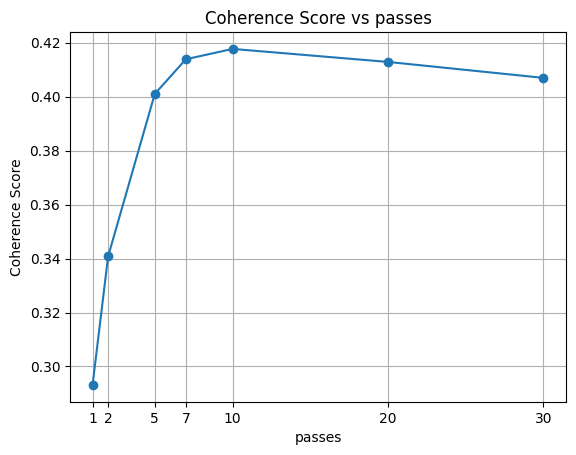

In [1]:
coherence_scores_per_passes = [(1, 0.29315842437530576),(2, 0.3408144505681058), (5, 0.4010248420013477), (7, 0.4138833456293545), (10, 0.41771456916823996), (20, 0.4128936872568252), (30, 0.4069795231919741)]

# plotting coherence scores
import matplotlib.pyplot as plt
passes, coherence_scores = zip(*coherence_scores_per_passes)
plt.plot(passes, coherence_scores, marker='o')
plt.title('Coherence Score vs passes')
plt.xlabel('passes')
plt.ylabel('Coherence Score')
plt.xticks(passes)
plt.grid()
plt.savefig("artifacts/LDA/lda-coherence-per-passes.png")
plt.show()

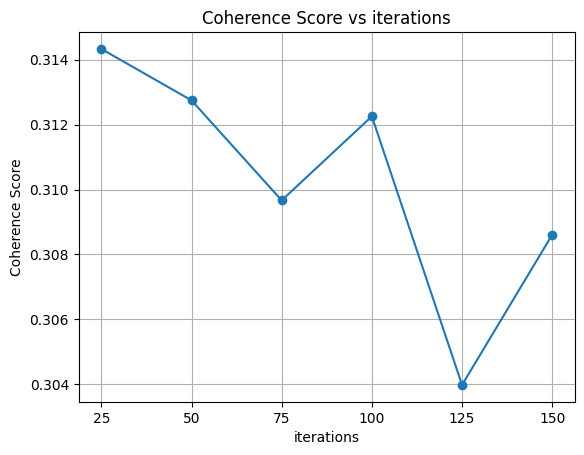

In [2]:
coherence_scores_per_iterations = [(25, 0.31433406272129466),(50, 0.3127485036571098), (75, 0.3096659906156267), (100, 0.3122561148668615), (125, 0.30397748180880324), (150, 0.3086079109748159)]

# plotting coherence scores
import matplotlib.pyplot as plt
iterations, coherence_scores = zip(*coherence_scores_per_iterations)
plt.plot(iterations, coherence_scores, marker='o')
plt.title('Coherence Score vs iterations')
plt.xlabel('iterations')
plt.ylabel('Coherence Score')
plt.xticks(iterations)
plt.grid()
plt.savefig("artifacts/LDA/lda-coherence-per-iterations.png")
plt.show()

## Instantiate and fit LDA model

In [22]:
import time

if load_lda_model:
    print("Loading existing LDA model...")
    topic_model = gensim.models.ldamulticore.LdaMulticore.load(f"artifacts/LDA/lda-{output_file_suffix}.model")
else:
    if corpus_type == "title":
        num_topics=85
    elif corpus_type == "concat":
        num_topics=75
    print("Training LDA model...")
    tick = time.time()
    topic_model = gensim.models.ldamulticore.LdaMulticore(
        corpus=dt_matrix,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=2718,
        passes=10,
        # iterations=50, is default
    )
    tack = time.time()
    with open(f"artifacts/LDA/lda-{output_file_suffix}-training-time.txt", "w") as f:
        f.write(f"{(tack - tick) / 60:.2f} minutes")

Loading existing LDA model...


### Print and write topics

In [23]:
print(topic_model.print_topics())

[(np.int64(51), '0.045*"temperature" + 0.024*"thermal" + 0.014*"solar" + 0.014*"water" + 0.010*"satellite" + 0.010*"earth" + 0.009*"heat" + 0.008*"atmospheric" + 0.008*"atmosphere" + 0.008*"model"'), (np.int64(31), '0.126*"variable" + 0.081*"causal" + 0.031*"treatment" + 0.028*"identification" + 0.020*"driver" + 0.019*"effect" + 0.018*"intervention" + 0.015*"graphical" + 0.014*"counterfactual" + 0.012*"outcome"'), (np.int64(36), '0.059*"feature" + 0.022*"attention" + 0.021*"information" + 0.021*"module" + 0.018*"spatial" + 0.014*"transformer" + 0.014*"fusion" + 0.012*"network" + 0.011*"proposed" + 0.011*"local"'), (np.int64(55), '0.087*"graph" + 0.024*"algorithm" + 0.018*"vertex" + 0.017*"complexity" + 0.017*"bound" + 0.014*"time" + 0.013*"number" + 0.013*"edge" + 0.012*"show" + 0.011*"result"'), (np.int64(68), '0.054*"expression" + 0.042*"emotion" + 0.024*"conversion" + 0.023*"cognitive" + 0.021*"emotional" + 0.014*"trait" + 0.013*"super" + 0.012*"abstraction" + 0.011*"contract" + 0.0

In [24]:
# print topics without weights

with open(f"artifacts/LDA/lda-{output_file_suffix}-topics.csv", "w") as f:
    f.write("topic_id;words\n")

for topic_id in range(topic_model.num_topics):
    topic_terms = topic_model.get_topic_terms(topic_id, topn=10)
    topic_words = [dictionary[word_id] for word_id, _ in topic_terms]
    print(f"Topic {topic_id}: {', '.join(topic_words)}")
    with open(f"artifacts/LDA/lda-{output_file_suffix}-topics.csv", "a") as f:
        f.write(f"{topic_id};")
        f.write(', '.join([word for word in topic_words]))
        f.write("\n")

Topic 0: attack, security, code, program, protocol, system, logic, verification, vulnerability, test
Topic 1: defect, circular, inspection, surgical, mar, aging, instrument, surgery, alice, physician
Topic 2: scattering, polarization, beam, resonance, angle, electron, photon, medium, radiation, intensity
Topic 3: coupling, oscillation, coupled, frequency, synchronization, chaotic, oscillator, chaos, collective, damping
Topic 4: network, node, link, edge, topology, connectivity, community, routing, graph, structure
Topic 5: forward, recurrent, automaton, drone, backward, recurrence, auction, shot, stopping, rnn
Topic 6: communication, proposed, power, performance, system, user, service, result, traffic, transmission
Topic 7: distribution, random, probability, sampling, stochastic, gaussian, density, kernel, moment, sample
Topic 8: field, model, term, gravity, symmetry, effective, potential, theory, also, two
Topic 9: agent, environment, task, robot, planning, human, interaction, action,

### Save the model

In [16]:
if not load_lda_model:
    topic_model.save(f"artifacts/LDA/lda-{output_file_suffix}.model")

## Evaluation

### Coherence

In [17]:
coherence_model = gensim.models.CoherenceModel(
    model=topic_model,
    texts=corpus,
    dictionary=dictionary,
)

print("Calculating coherence...")
coherence = coherence_model.get_coherence()

print(f'Coherence: {coherence}')
with open(f"artifacts/LDA/lda-{output_file_suffix}.coherence", "w") as f:
    f.write(f'{coherence}\n')

Calculating coherence...


Coherence: 0.49001094927303435


# Run optionally to shutdown Dask client

In [18]:
client.close()